# Benchmark asynchronous work correctly

CPU companion; no accelerator is required. TPU execution not validated.

- Draw the interval a timing actually measures.
- Exclude initial placement from a device-resident benchmark.
- Check an independent NumPy result before comparing timings.
- Produce a report containing first-call and warmed sample distributions.

A first timing suggests a tenfold speedup. Before celebrating, let’s ask when the timer started and stopped. We’ll separate the first call from warm calls, wait for JAX to finish, and compare numerical results. By the end, you’ll have a timing report another learner can reproduce.

## The idea

JAX can return an array handle before device work finishes. A benchmark must define what starts the interval and what counts as completion. First-call preparation, warm execution and end-to-end requests answer different performance questions.

## Time a completed result

If a timer stops as soon as dispatch returns, it may exclude most of the computation. Blocking on the result inside the interval includes completion of the work required to produce that result.

Warm up the intended specialization before measuring repeated execution, and retain startup separately if it matters to the application. Include preprocessing and transfers in a separately named end-to-end measurement when they belong to the request.

The first-call and warm bars represent different intervals. Their ratio depends on the workload and environment. A short dispatch time is not evidence of device throughput, and a warm kernel timing does not describe an entire service request.

### Time the completed result

**Predict:** Where should synchronization occur in completed-result latency measurement?

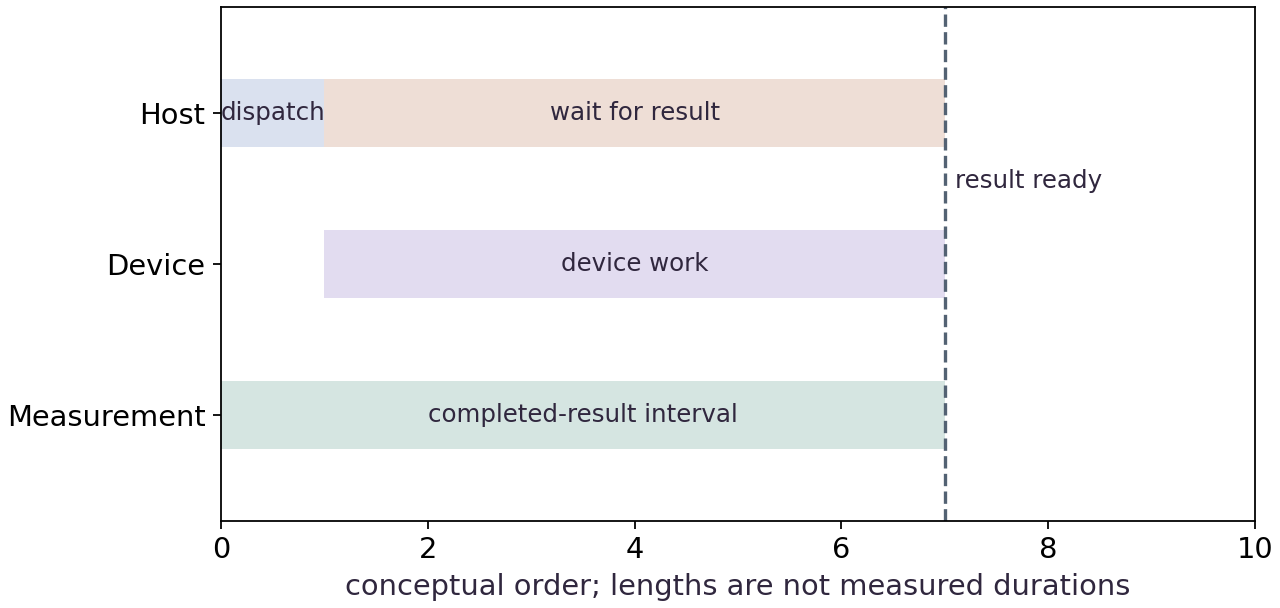

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

The host dispatches and waits while device work proceeds. The measurement lane includes readiness. Lengths illustrate ordering only and are not measured durations. Compilation and data preparation need separately chosen boundaries when included in a benchmark.

### Pause and reason

Where should synchronization occur in completed-result latency measurement?

<details><summary>Compare your reasoning</summary>

Before stopping the timer. Synchronizing afterward can omit unfinished work from the reported interval.

</details>

## Draw the boundary before starting the clock

For our workload, the input has shape $(64, 32)$, the weights have shape $(32, 16)$, and the result has shape $(64, 16)$. Matrix multiplication contracts the feature dimension, then tanh transforms each prediction. The timer starts after both input arrays are placed on CPU and ready. It stops after the output is ready.

That interval includes Python dispatch, execution and the final wait. It is not an isolated kernel duration. Data generation, initial placement and output conversion to NumPy are outside it. A serving request or data-loading benchmark would deliberately include different boundaries; specify which question your measurement answers.

```text
prepare host arrays → place → wait | start → call → result handle → wait → stop | inspect host values
```

## A handle is not proof of completion

Python can receive a JAX array before its contents finish computing. Reading shape or dtype can use metadata without reading the values. Calling block_until_ready on the result waits for readiness. Converting it to NumPy also requires the values, but adds a host-materialization boundary.

CPU dispatch behavior and workload size may make the difference difficult to see. If a handle-only interval is close to a synchronized interval on this machine, that does not justify removing synchronization from a portable benchmark. Timing two independent calls cannot be subtracted to obtain an exact queue or execution cost.

## First call and steady state answer different questions

A fresh jitted function can trace its Python body, lower the resulting program, obtain an executable and run it. The first-call timer combines these stages. Persistent caches and prior process activity can alter the result, so call it first-call latency for this process rather than an exact compilation measurement.

We then run seven synchronized repeats with identical shapes and dtypes. The list reveals variation; the median gives a compact center. Seven samples are an instructional start, not a confidence interval. Increase repetitions and document contention, power state and process initialization before drawing deployment conclusions.

## Correctness comes before a speed ratio

The NumPy reference uses the same float32 inputs and computes the same matrix product and tanh. Floating-point reduction order can vary, so the comparison permits small absolute and relative differences rather than demanding bit equality. We record maximum absolute error as well.

Comparing a float64 reference against an unreported float32 JAX computation, or comparing different matrix sizes, would mix numerical work with implementation differences. A faster answer to a different problem is not evidence of optimization. Retain both workload contracts and both checks in the report.

## Prepare and place the workload

Create benchmark.py in your activated course environment and add this block.

In [1]:
import json
import platform
import time
import statistics
import numpy as np
import jax
import jax.numpy as jnp
cpu = jax.devices("cpu")[0]
rng = np.random.default_rng(4)
x_host = rng.normal(size=(64, 32)).astype(np.float32)
w_host = rng.normal(size=(32, 16)).astype(np.float32)
x = jax.device_put(x_host, cpu)
w = jax.device_put(w_host, cpu)
jax.block_until_ready((x, w))


CPU placement and waiting occur before timing. The deterministic host inputs make the numerical check reproducible.

## Define the contract and timer

Append this block to the same file. Run the assembled file with python benchmark.py.

In [2]:
def predict(x, w):
    return jnp.tanh(x @ w)
compiled_predict = jax.jit(predict)
def synchronized_samples(fn, args, repeats=7):
    if repeats < 1:
        raise ValueError("at least one repeat is required")
    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        result = fn(*args)
        jax.block_until_ready(result)
        samples.append(time.perf_counter() - start)
    return result, samples


The timer accepts arbitrary result pytrees because `jax.block_until_ready` waits across their array leaves. It collects observations without asserting which implementation is faster.

## Separate first call from warm calls

Append this block to the same file. Run the assembled file with python benchmark.py.

In [3]:
start = time.perf_counter()
first = compiled_predict(x, w)
first.block_until_ready()
first_call_seconds = time.perf_counter() - start
result, samples = synchronized_samples(compiled_predict, (x, w))
reference = np.tanh(x_host @ w_host)
np.testing.assert_allclose(np.asarray(result), reference, atol=2e-5, rtol=2e-5)
report = {
    "backend": str(cpu), "jax": jax.__version__, "numpy": np.__version__,
    "python": platform.python_version(), "input_shape": list(x.shape),
    "weight_shape": list(w.shape), "dtype": str(x.dtype),
    "boundary": "input already placed; call plus output synchronization",
    "first_call_seconds": first_call_seconds,
    "warm_samples_seconds": samples, "warm_median_seconds": statistics.median(samples),
    "max_abs_error": float(np.max(np.abs(np.asarray(result) - reference))),
}
assert len(samples) == 7 and all(t >= 0 for t in samples)
print(json.dumps(report, indent=2))


{
  "backend": "TFRT_CPU_0",
  "jax": "0.9.2",
  "numpy": "2.4.4",
  "python": "3.14.3",
  "input_shape": [
    64,
    32
  ],
  "weight_shape": [
    32,
    16
  ],
  "dtype": "float32",
  "boundary": "input already placed; call plus output synchronization",
  "first_call_seconds": 0.02845375007018447,
  "warm_samples_seconds": [
    2.8541311621665955e-05,
    1.4124903827905655e-05,
    1.3125129044055939e-05,
    1.0166317224502563e-05,
    7.958151400089264e-06,
    7.333233952522278e-06,
    7.291790097951889e-06
  ],
  "warm_median_seconds": 1.0166317224502563e-05,
  "max_abs_error": 2.384185791015625e-07
}


The report prints variable measured times. Redirect the full run output to a text file and keep the benchmark script with it.

## Run the example

In [4]:
import json
import platform
import time
import statistics
import numpy as np
import jax
import jax.numpy as jnp
cpu = jax.devices("cpu")[0]
rng = np.random.default_rng(4)
x_host = rng.normal(size=(64, 32)).astype(np.float32)
w_host = rng.normal(size=(32, 16)).astype(np.float32)
x = jax.device_put(x_host, cpu)
w = jax.device_put(w_host, cpu)
jax.block_until_ready((x, w))

def predict(x, w):
    return jnp.tanh(x @ w)
compiled_predict = jax.jit(predict)
def synchronized_samples(fn, args, repeats=7):
    if repeats < 1:
        raise ValueError("at least one repeat is required")
    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        result = fn(*args)
        jax.block_until_ready(result)
        samples.append(time.perf_counter() - start)
    return result, samples

start = time.perf_counter()
first = compiled_predict(x, w)
first.block_until_ready()
first_call_seconds = time.perf_counter() - start
result, samples = synchronized_samples(compiled_predict, (x, w))
reference = np.tanh(x_host @ w_host)
np.testing.assert_allclose(np.asarray(result), reference, atol=2e-5, rtol=2e-5)
report = {
    "backend": str(cpu), "jax": jax.__version__, "numpy": np.__version__,
    "python": platform.python_version(), "input_shape": list(x.shape),
    "weight_shape": list(w.shape), "dtype": str(x.dtype),
    "boundary": "input already placed; call plus output synchronization",
    "first_call_seconds": first_call_seconds,
    "warm_samples_seconds": samples, "warm_median_seconds": statistics.median(samples),
    "max_abs_error": float(np.max(np.abs(np.asarray(result) - reference))),
}
assert len(samples) == 7 and all(t >= 0 for t in samples)
print(json.dumps(report, indent=2))


{
  "backend": "TFRT_CPU_0",
  "jax": "0.9.2",
  "numpy": "2.4.4",
  "python": "3.14.3",
  "input_shape": [
    64,
    32
  ],
  "weight_shape": [
    32,
    16
  ],
  "dtype": "float32",
  "boundary": "input already placed; call plus output synchronization",
  "first_call_seconds": 0.01703258277848363,
  "warm_samples_seconds": [
    3.1416770070791245e-05,
    1.7541926354169846e-05,
    1.0666903108358383e-05,
    8.500181138515472e-06,
    8.458271622657776e-06,
    8.417293429374695e-06,
    7.417052984237671e-06
  ],
  "warm_median_seconds": 8.500181138515472e-06,
  "max_abs_error": 2.384185791015625e-07
}


Expected: A JSON benchmark report: input_shape $[64, 32]$, weight_shape $[32, 16]$, dtype float32, seven nonnegative warmed samples, and a checked maximum error. Times vary by run; there is no required speedup.

## Separate the first call from warm measurements

Predict: Why should the first call not be averaged into steady-state latency?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'panels', 'panels': [{'kind': 'bar', 'title': 'First call', 'labels': ['first'], 'ylabel': 'seconds', 'series': [{'label': 'synchronized call', 'y': [first_call_seconds]}]}, {'kind': 'line', 'title': 'Warm calls', 'x': list(range(1, len(samples) + 1)), 'xlabel': 'warm sample', 'ylabel': 'seconds', 'series': [{'label': 'synchronized call', 'y': samples}]}]}

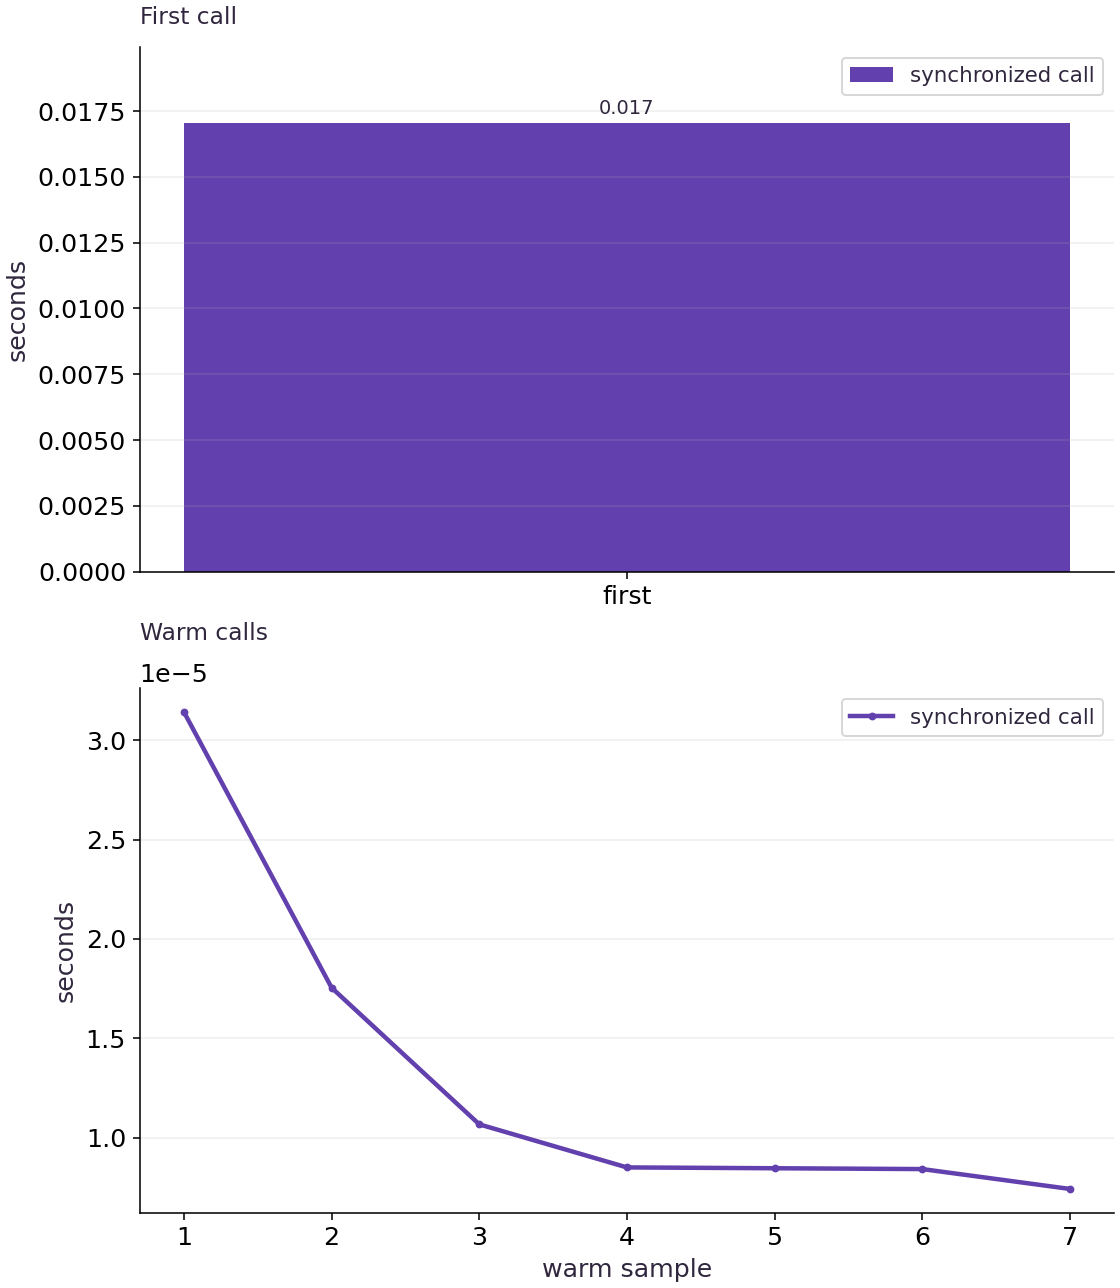

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The upper panel measures the first synchronized call. The lower panel measures repeated warm calls, with sample number on the horizontal axis. Both report seconds, but they have independent vertical scales. Compare the tick values and any scientific-notation multiplier, not the physical heights of the panels.

The recorded first call is much longer than the warm calls. For orientation, $10^{-2}$ seconds is $10$ milliseconds, while $10^{-5}$ seconds is $10$ microseconds. A multiplier printed beside an axis applies to all its tick labels; overlooking it can hide a difference of orders of magnitude.

### Connect it to the computation

The first measurement includes work needed to prepare this specialization, including tracing and compilation. Compatible warm calls reuse it. Each measurement waits for the result, so it includes completed computation rather than only the time needed to dispatch work. Inputs are already placed before this measured boundary.

The warm line shows variation between individual samples. An isolated higher point is a slower sample, not proof of recompilation or a changing model. Read the recorded median alongside the full sample list, and rerun before comparing implementations. These measurements describe this small CPU workload; they do not establish accelerator speed or end-to-end request latency.

## Compare handle-only and synchronized boundaries

Predict: Will the handle-only number necessarily be smaller on this CPU? Which interval guarantees output completion?

In [7]:
start = time.perf_counter()
handle = compiled_predict(x, w)
handle_seconds = time.perf_counter() - start
handle.block_until_ready()  # drain this call before the separate comparison
_, complete_samples = synchronized_samples(compiled_predict, (x, w), repeats=3)
print("Handle-only seconds:", handle_seconds)
print("Complete-call samples:", complete_samples)


Handle-only seconds: 6.525032222270966e-05
Complete-call samples: [3.183400258421898e-05, 1.7666257917881012e-05, 1.020822674036026e-05]


Expected: One handle-only interval and three complete-call intervals, all observed rather than fixed.

The separate intervals have different measurement boundaries and noise. Only synchronized samples guarantee completed output before the timer stops; no strict timing ordering is asserted.

## Return structured results without host copies

Predict: If a function returns predictions and their mean, does waiting for the prediction alone clearly document the readiness of every reported result?

In [8]:
structured = jax.jit(lambda a, b: {"prediction": jnp.tanh(a @ b), "mean": jnp.mean(jnp.tanh(a @ b))})
jax.block_until_ready(structured(x, w))
structured_result, structured_times = synchronized_samples(structured, (x, w), 3)
np.testing.assert_allclose(np.asarray(structured_result["prediction"]), reference, atol=2e-5, rtol=2e-5)
np.testing.assert_allclose(np.asarray(structured_result["mean"]), reference.mean(), atol=2e-5, rtol=2e-5)
print("Structured samples:", structured_times)


Structured samples: [3.758305683732033e-05, 2.2666994482278824e-05, 1.616682857275009e-05]


Expected: Three timings and independently verified prediction/mean leaves.

A tree-level wait makes the benchmark contract explicit for every array leaf. Host inspection occurs after the timer, so the report describes device-ready computation rather than transfer-inclusive output consumption.

## Your exercise

Repeat the benchmark with $96$ rows while preserving the feature and output dimensions. Keep a separate report rather than overwriting the original workload label.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
larger_host = rng.normal(size=(96, 32)).astype(np.float32)
larger = jax.device_put(larger_host, cpu)
larger.block_until_ready()
compiled_predict(larger, w).block_until_ready()
larger_result, larger_times = synchronized_samples(compiled_predict, (larger, w), 5)
np.testing.assert_allclose(np.asarray(larger_result), np.tanh(larger_host @ w_host), atol=2e-5, rtol=2e-5)
print("Changed workload:", larger.shape, larger_times)


Changed workload: (96, 32) [2.7916859835386276e-05, 1.0541640222072601e-05, 7.624737918376923e-06, 9.582843631505966e-06, 9.458977729082108e-06]


## Benchmark a different equivalent workload · Transfer

Replace tanh with a row-wise sum of squared predictions, returning one scalar per row. Derive the NumPy reference, warm this new function, collect five synchronized samples and record the changed output shape.

Hint: Square before reducing the output-feature axis; the result has shape $(64,)$.

In [11]:
# Write your attempt here.

## Reference reasoning

Changing the computation changes the performance question. The shape and independent numerical check prevent a benchmark from accidentally timing an unrelated scalar reduction.

In [12]:
energy = jax.jit(lambda a, b: jnp.sum((a @ b)**2, axis=1))
energy(x, w).block_until_ready()
energy_result, energy_times = synchronized_samples(energy, (x, w), 5)
energy_reference = np.sum((x_host @ w_host)**2, axis=1)
assert energy_result.shape == (64,)
np.testing.assert_allclose(np.asarray(energy_result), energy_reference, atol=2e-3, rtol=2e-5)
print("Energy shape and samples:", energy_result.shape, energy_times)


Energy shape and samples: (64,) [2.695806324481964e-05, 1.037493348121643e-05, 9.374693036079407e-06, 7.4999406933784485e-06, 1.0333023965358734e-05]


## Repair a timer that includes setup but omits completion · Diagnosis

Inspect the broken timer below conceptually: start; create inputs; call `jit(predict)(inputs)`; stop. Write a repaired runner and show its explicit boundary. Explain which stages the broken interval mixes and misses.

Hint: Prepare and wait for inputs, reuse one compiled callable, warm it, then synchronize the returned output inside every measured interval.

In [13]:
# Write your attempt here.

## Reference reasoning

The repaired boundary excludes setup, separates warmup and waits before stopping. A speedup cannot be reconstructed from the flawed interval; rerun both implementations under the same contract.

In [14]:
def repaired_benchmark(fn, args):
    jax.block_until_ready(args)
    jax.block_until_ready(fn(*args))
    result, measured = synchronized_samples(fn, args, 5)
    return {"boundary": "placed inputs; warm call plus output wait", "samples": measured}, result
fixed_report, fixed_result = repaired_benchmark(compiled_predict, (x, w))
np.testing.assert_allclose(np.asarray(fixed_result), reference, atol=2e-5, rtol=2e-5)
assert len(fixed_report["samples"]) == 5
print(fixed_report)


{'boundary': 'placed inputs; warm call plus output wait', 'samples': [1.8291175365447998e-05, 1.2042000889778137e-05, 8.792150765657425e-06, 8.541624993085861e-06, 6.833113729953766e-06]}


## Checkpoint

What does the synchronized warmed timer in this lesson measure?

1. Only the accelerator kernel, with all dispatch overhead removed
2. A warmed call including dispatch and waiting for output readiness, excluding prior input placement
3. Exactly the compiler duration

## Diagnose

If samples vary, first check workload identity, dtype, the warmup call, where synchronization occurs and system contention. Do not change a timer until its start/stop boundary answers the intended question.

## Evidence

Keep benchmark.py, complete observed JSON/sample output, workload shapes/dtypes, numerical tolerance/error, first-call versus warmed boundaries, changed-workload report and repaired timer explanation.

## Carry forward

- Keep first-call latency separate from warmed samples.
- Wait for results before reporting completed computation.
- Report numerical equivalence and workload details beside times.

## Primary references

- [Benchmarking JAX code](https://docs.jax.dev/en/latest/benchmarking.html)
- [Asynchronous dispatch](https://docs.jax.dev/en/latest/async_dispatch.html)